# DICOM Multi-Window Preprocessing (Resumable) - Google Colab

## Traitement de 7000 images DICOM avec fenêtres médicales (Poumons, Médiastin, Os)

Ce notebook traite les fichiers DICOM du dossier `dataset_dicom` en appliquant un prétraitement multi-fenêtre pour encoder 3 perspectives médicales dans une seule image PNG 3-canaux (RGB).

**Processus:**
- **Entrée:** Fichiers DICOM 16-bit du dossier `dataset_dicom/`
- **Fenêtres appliquées:**
  - 🔴 **Lungs (Rouge):** WL adapté - 20% range, WW = 60% range (parenchyme pulmonaire)
  - 🟢 **Mediastinum (Vert):** WL adapté, WW = 30% range (structures médiastinales)
  - 🔵 **Bone (Bleu):** WL adapté + 15% range, WW = 50% range (structures osseuses)
- **Sortie:** Images PNG RGB 3-canaux sauvegardées dans Google Drive

**Résultat:** Une seule image pour chaque DICOM, avec 3 perspectives médicales encodées en RGB

## 1️⃣ Installer et importer les bibliothèques

In [1]:
!pip install pydicom -q
!pip install pillow -q

print("✅ Installation des packages terminée")
print("Packages installés: pydicom, pillow, numpy, matplotlib")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 18.7 MB/s eta 0:00:00
✅ Installation des packages terminée
Packages installés: pydicom, pillow, numpy, matplotlib


In [2]:
import os
import numpy as np
import pydicom
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import time
from datetime import datetime

print("✅ Imports réussis")
print(f"pydicom version: {pydicom.__version__}")
print(f"NumPy version: {np.__version__}")

✅ Imports réussis
pydicom version: 3.0.2
NumPy version: 2.0.2


## 2️⃣ Monter Google Drive et accéder au dossier dataset_dicom

In [3]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')
print("✅ Google Drive monté avec succès")

Mounted at /content/drive
✅ Google Drive monté avec succès


In [4]:
# Configuration des chemins
# Remplacer 'MM-MIA' par le chemin exact dans ton Drive si nécessaire
DRIVE_BASE = "/content/drive/My Drive"
PROJECT_FOLDER = "artishow"  # Nom du dossier principal
DICOM_FOLDER = "dataset_dicom"  # Nom du dossier contenant les DICOM

# Construire les chemins
project_path = os.path.join(DRIVE_BASE, PROJECT_FOLDER)
dicom_path = os.path.join(project_path, DICOM_FOLDER)

print(f"📁 Chemin du projet: {project_path}")
print(f"📁 Chemin des DICOM: {dicom_path}")

# Vérifier que le dossier existe
if os.path.exists(dicom_path):
    print(f"✅ Dossier {DICOM_FOLDER} trouvé")
else:
    print(f"❌ Dossier {DICOM_FOLDER} non trouvé à {dicom_path}")
    print(f"Contenu du projet:")
    if os.path.exists(project_path):
        for item in os.listdir(project_path):
            print(f"  - {item}")

📁 Chemin du projet: /content/drive/My Drive/artishow
📁 Chemin des DICOM: /content/drive/My Drive/artishow/dataset_dicom
✅ Dossier dataset_dicom trouvé


## 3️⃣ Charger et explorer les fichiers DICOM

In [5]:
# Trouver tous les fichiers DICOM
dicom_files = []
for root, dirs, files in os.walk(dicom_path):
    for file in files:
        if file.lower().endswith('.dcm'):
            dicom_files.append(os.path.join(root, file))

print(f"🔍 Fichiers DICOM trouvés: {len(dicom_files)}")
print(f"\n📋 Premiers 10 fichiers DICOM:")
for i, f in enumerate(sorted(dicom_files)[:10], 1):
    filename = os.path.basename(f)
    print(f"  {i:3d}. {filename}")

🔍 Fichiers DICOM trouvés: 7470

📋 Premiers 10 fichiers DICOM:
    1. 1_IM-0001-3001.dcm
    2. 1_IM-0001-4001.dcm
    3. 10_IM-0002-1001.dcm
    4. 10_IM-0002-2001.dcm
    5. 100_IM-0002-1001.dcm
    6. 100_IM-0002-2001.dcm
    7. 1000_IM-0003-1001.dcm
    8. 1000_IM-0003-2001.dcm
    9. 1000_IM-0003-3001.dcm
   10. 1001_IM-0004-1001.dcm


In [6]:
# Charger et afficher les infos du premier DICOM
if dicom_files:
    first_dicom = sorted(dicom_files)[0]
    print(f"📖 Chargement du premier DICOM: {os.path.basename(first_dicom)}\n")

    dcm = pydicom.dcmread(first_dicom)
    print(f"Patient ID: {dcm.get('PatientID', 'N/A')}")
    print(f"Modalité: {dcm.get('Modality', 'N/A')}")
    print(f"Dimensions: {dcm.pixel_array.shape}")
    print(f"Type de données: {dcm.pixel_array.dtype}")
    print(f"Plage de pixels: [{dcm.pixel_array.min()}, {dcm.pixel_array.max()}]")
    print(f"Moyenne pixels: {dcm.pixel_array.mean():.2f}")
else:
    print("❌ Aucun fichier DICOM trouvé")

📖 Chargement du premier DICOM: 1_IM-0001-3001.dcm

Patient ID: 1
Modalité: CR
Dimensions: (2828, 2320)
Type de données: uint16
Plage de pixels: [12230, 32466]
Moyenne pixels: 23582.60


## 4️⃣ Afficher les images DICOM avec les fenêtres médicales

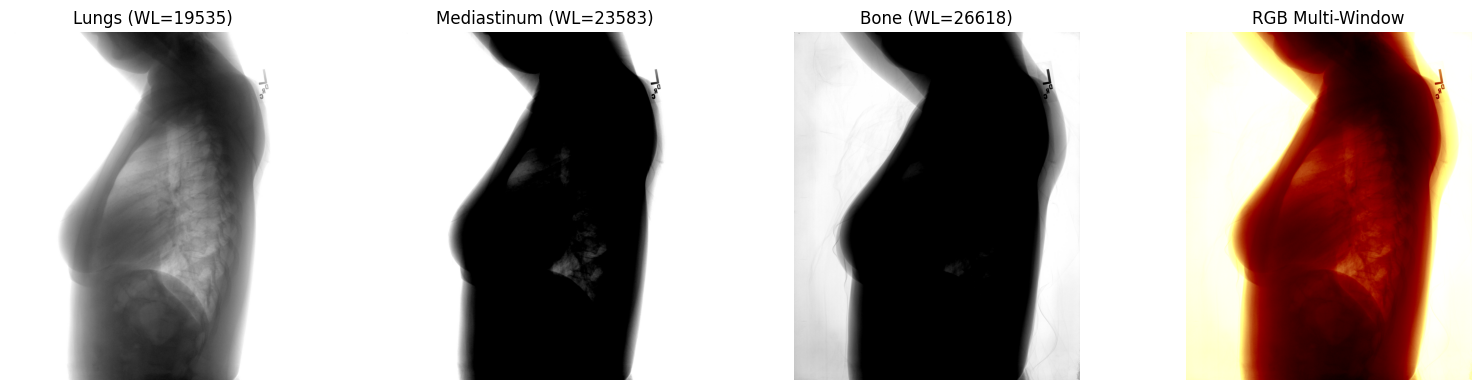

✅ Visualisation des fenêtres réussie


In [7]:
def adapt_windows_to_pixel_range(pixel_array):
    """Adapte les fenêtres en fonction de la plage réelle des pixels"""
    pixel_min = pixel_array.min()
    pixel_max = pixel_array.max()
    pixel_mean = pixel_array.mean()
    pixel_range = pixel_max - pixel_min

    adapted_windows = {
        "lungs": {
            "level": pixel_mean - pixel_range * 0.2,
            "width": pixel_range * 0.6
        },
        "mediastinum": {
            "level": pixel_mean,
            "width": pixel_range * 0.3
        },
        "bone": {
            "level": pixel_mean + pixel_range * 0.15,
            "width": pixel_range * 0.5
        }
    }
    return adapted_windows

def apply_window(pixel_array, window_level, window_width):
    """Applique une fenêtre DICOM et convertit 16-bit → 8-bit"""
    lower = window_level - window_width / 2
    upper = window_level + window_width / 2
    windowed = np.clip(pixel_array, lower, upper)
    windowed = ((windowed - lower) / (upper - lower) * 255).astype(np.uint8)
    return windowed

# Visualiser les fenêtres sur le premier DICOM
if dicom_files:
    dcm = pydicom.dcmread(sorted(dicom_files)[0])
    pixel_array = dcm.pixel_array.astype(np.float32)

    # Appliquer rescaling si présent
    if hasattr(dcm, 'RescaleIntercept') and hasattr(dcm, 'RescaleSlope'):
        pixel_array = pixel_array * dcm.RescaleSlope + dcm.RescaleIntercept

    windows = adapt_windows_to_pixel_range(pixel_array)

    # Appliquer les 3 fenêtres
    lungs = apply_window(pixel_array, windows["lungs"]["level"], windows["lungs"]["width"])
    mediastinum = apply_window(pixel_array, windows["mediastinum"]["level"], windows["mediastinum"]["width"])
    bone = apply_window(pixel_array, windows["bone"]["level"], windows["bone"]["width"])
    rgb_image = np.stack([lungs, mediastinum, bone], axis=2)

    # Afficher
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(lungs, cmap='gray')
    axes[0].set_title(f"Lungs (WL={windows['lungs']['level']:.0f})")
    axes[0].axis('off')

    axes[1].imshow(mediastinum, cmap='gray')
    axes[1].set_title(f"Mediastinum (WL={windows['mediastinum']['level']:.0f})")
    axes[1].axis('off')

    axes[2].imshow(bone, cmap='gray')
    axes[2].set_title(f"Bone (WL={windows['bone']['level']:.0f})")
    axes[2].axis('off')

    axes[3].imshow(rgb_image)
    axes[3].set_title("RGB Multi-Window")
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

    print("✅ Visualisation des fenêtres réussie")

## 5️⃣ Extraire les métadonnées DICOM

In [8]:
# Extraire les métadonnées de quelques fichiers DICOM
metadata_list = []

print("📊 Extraction des métadonnées des 20 premiers fichiers DICOM\n")

for i, dicom_file in enumerate(sorted(dicom_files)[:20], 1):
    try:
        dcm = pydicom.dcmread(dicom_file)
        filename = os.path.basename(dicom_file)

        metadata = {
            'Filename': filename,
            'PatientID': str(dcm.get('PatientID', 'N/A')),
            'Modality': str(dcm.get('Modality', 'N/A')),
            'StudyDate': str(dcm.get('StudyDate', 'N/A')),
            'StudyTime': str(dcm.get('StudyTime', 'N/A')),
            'Rows': int(dcm.get('Rows', 0)),
            'Columns': int(dcm.get('Columns', 0)),
            'BitsAllocated': int(dcm.get('BitsAllocated', 0)),
            'PixelMin': int(dcm.pixel_array.min()),
            'PixelMax': int(dcm.pixel_array.max()),
        }
        metadata_list.append(metadata)

        if i <= 3:
            print(f"{i}. {filename}")
            for key, val in metadata.items():
                if key != 'Filename':
                    print(f"   {key}: {val}")
            print()
    except Exception as e:
        print(f"   ❌ Erreur lecture: {e}")

print(f"✅ {len(metadata_list)} métadonnées extraites")

📊 Extraction des métadonnées des 20 premiers fichiers DICOM

1. 1_IM-0001-3001.dcm
   PatientID: 1
   Modality: CR
   StudyDate: 20120229
   StudyTime: 
   Rows: 2828
   Columns: 2320
   BitsAllocated: 16
   PixelMin: 12230
   PixelMax: 32466

2. 1_IM-0001-4001.dcm
   PatientID: 1
   Modality: CR
   StudyDate: 20120229
   StudyTime: 
   Rows: 2320
   Columns: 2828
   BitsAllocated: 16
   PixelMin: 12944
   PixelMax: 31367

3. 10_IM-0002-1001.dcm
   PatientID: 10
   Modality: CR
   StudyDate: 20110320
   StudyTime: 
   Rows: 2828
   Columns: 2320
   BitsAllocated: 16
   PixelMin: 1355
   PixelMax: 4095

✅ 20 métadonnées extraites


## 6️⃣ Prétraitement multi-fenêtre et sauvegarde des images PNG

### Configuration du traitement par batch

In [9]:
def process_dicom(dicom_path):
    """Charge DICOM, applique les 3 windows, retourne l'image RGB"""
    try:
        dcm = pydicom.dcmread(dicom_path)
        pixel_array = dcm.pixel_array.astype(np.float32)

        # Appliquer rescaling si présent
        if hasattr(dcm, 'RescaleIntercept') and hasattr(dcm, 'RescaleSlope'):
            pixel_array = pixel_array * dcm.RescaleSlope + dcm.RescaleIntercept

        # Adapter les fenêtres
        windows = adapt_windows_to_pixel_range(pixel_array)

        # Appliquer les 3 fenêtres
        lungs = apply_window(pixel_array, windows["lungs"]["level"], windows["lungs"]["width"])
        mediastinum = apply_window(pixel_array, windows["mediastinum"]["level"], windows["mediastinum"]["width"])
        bone = apply_window(pixel_array, windows["bone"]["level"], windows["bone"]["width"])

        # Stack en RGB
        rgb_image = np.stack([lungs, mediastinum, bone], axis=2)
        return rgb_image, None
    except Exception as e:
        return None, str(e)

# Configuration de la sortie
OUTPUT_FOLDER = os.path.join(project_path, "preprocessed_images_multiwindow")
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

print(f"📁 Dossier de sortie créé: {OUTPUT_FOLDER}")
print(f"📊 Total DICOM à traiter: {len(dicom_files)} fichiers")

📁 Dossier de sortie créé: /content/drive/My Drive/artishow/preprocessed_images_multiwindow
📊 Total DICOM à traiter: 7470 fichiers


### Traitement de tous les fichiers DICOM

⚠️ **Note:** Selon la taille de ta collection DICOM, ce traitement peut prendre du temps.

Pour 7000 fichiers, on estime environ quelques heures sur GPU Colab.

In [11]:
from tqdm import tqdm

print("=" * 80)
print("🚀 DÉBUT DU TRAITEMENT MULTI-FENÊTRE (MODE REPRISE)")
print("=" * 80)
print(f"Début: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Nombre de fichiers: {len(dicom_files)}\n")

start_time = time.time()
success_count = 0
error_count = 0
errors_log = []

# Traiter chaque DICOM
for idx, dicom_path in enumerate(tqdm(sorted(dicom_files), desc="Traitement"), 1):
    filename = os.path.basename(dicom_path)
    filename_base = os.path.splitext(filename)[0]
    output_path = os.path.join(OUTPUT_FOLDER, f"{filename_base}_multiwindow.png")

    # --- NOUVEAU: Reprise après interruption ---
    if os.path.exists(output_path):
        success_count += 1
        continue
    # -------------------------------------------

    # Traiter
    rgb_image, error = process_dicom(dicom_path)

    if rgb_image is not None:
        # Sauvegarder
        try:
            Image.fromarray(rgb_image, mode='RGB').save(output_path, quality=95)
            success_count += 1
        except Exception as e:
            error_count += 1
            errors_log.append((filename, f"Erreur sauvegarde: {str(e)}"))
    else:
        error_count += 1
        errors_log.append((filename, error))

elapsed_time = time.time() - start_time

print("\n" + "=" * 80)
print("✅ TRAITEMENT TERMINÉ")
print("=" * 80)
print(f"Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Durée totale: {elapsed_time / 60:.1f} minutes ({elapsed_time / 3600:.1f} heures)")
print(f"\n📊 Résultats:")
print(f"   ✅ Fichiers traités avec succès: {success_count}/{len(dicom_files)} ({success_count/len(dicom_files)*100:.1f}%)")
print(f"   ❌ Erreurs: {error_count}/{len(dicom_files)}")
print(f"   ⏱️ Temps moyen par fichier: {elapsed_time/len(dicom_files):.2f}s")

if errors_log:
    print(f"\n⚠️ Fichiers en erreur:")
    for filename, error in errors_log[:10]:
        print(f"   - {filename}: {error}")
    if len(errors_log) > 10:
        print(f"   ... et {len(errors_log) - 10} autres erreurs")

🚀 DÉBUT DU TRAITEMENT MULTI-FENÊTRE (MODE REPRISE)
Début: 2026-06-24 20:40:40
Nombre de fichiers: 7470



Traitement:  97%|█████████▋| 7263/7470 [00:02<00:00, 2722.53it/s]/tmp/ipykernel_4224/4033090105.py:32: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(rgb_image, mode='RGB').save(output_path, quality=95)
Traitement: 100%|██████████| 7470/7470 [08:47<00:00, 14.17it/s]


✅ TRAITEMENT TERMINÉ
Fin: 2026-06-24 20:49:27
Durée totale: 8.8 minutes (0.1 heures)

📊 Résultats:
   ✅ Fichiers traités avec succès: 7470/7470 (100.0%)
   ❌ Erreurs: 0/7470
   ⏱️ Temps moyen par fichier: 0.07s


### Vérification des résultats

📊 Fichiers PNG générés: 7470
📁 Dossier de sortie: /content/drive/My Drive/artishow/preprocessed_images_multiwindow

📦 Taille moyenne par image PNG: 7.79 MB
💾 Espace total utilisé: 56.86 GB



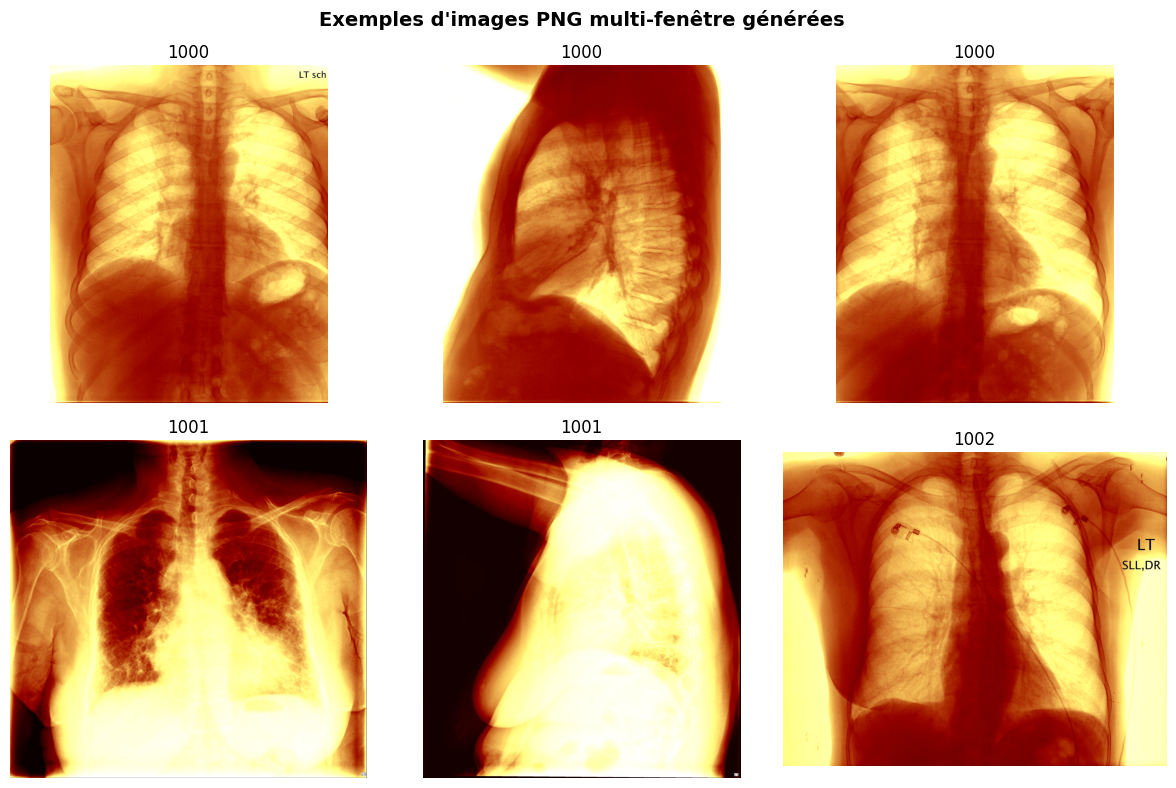

In [12]:
# Vérifier les fichiers de sortie
output_files = [f for f in os.listdir(OUTPUT_FOLDER) if f.endswith('.png')]

print(f"📊 Fichiers PNG générés: {len(output_files)}")
print(f"📁 Dossier de sortie: {OUTPUT_FOLDER}\n")

# Vérifier la taille des fichiers
if output_files:
    sizes = [os.path.getsize(os.path.join(OUTPUT_FOLDER, f)) for f in output_files]
    avg_size = np.mean(sizes)
    print(f"📦 Taille moyenne par image PNG: {avg_size / 1024 / 1024:.2f} MB")
    print(f"💾 Espace total utilisé: {sum(sizes) / 1024 / 1024 / 1024:.2f} GB\n")

# Afficher quelques exemples
if output_files:
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    fig.suptitle("Exemples d'images PNG multi-fenêtre générées", fontsize=14, fontweight='bold')

    sample_files = sorted(output_files)[:6]

    for idx, png_file in enumerate(sample_files):
        row = idx // 3
        col = idx % 3

        png_path = os.path.join(OUTPUT_FOLDER, png_file)
        img = Image.open(png_path)

        axes[row, col].imshow(img)
        axes[row, col].set_title(png_file.split('_')[0])
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

## 📝 Rapport de traitement et sauvegarde

Générer et sauvegarder un rapport complet du traitement dans Google Drive

In [13]:
# Créer un rapport de traitement
report = f"""
# RAPPORT DE TRAITEMENT DICOM MULTI-FENÊTRE
# Généré le: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

## CONFIGURATION
- Dossier source: {dicom_path}
- Dossier de sortie: {OUTPUT_FOLDER}
- Nombre total de fichiers DICOM: {len(dicom_files)}

## RÉSULTATS
- Fichiers traités avec succès: {success_count}/{len(dicom_files)} ({success_count/len(dicom_files)*100:.1f}%)
- Fichiers en erreur: {error_count}/{len(dicom_files)} ({error_count/len(dicom_files)*100:.1f}%)
- Durée totale: {elapsed_time / 60:.1f} minutes ({elapsed_time / 3600:.1f} heures)
- Temps moyen par fichier: {elapsed_time/len(dicom_files):.2f}s

## IMAGES GÉNÉRÉES
- Nombre total d'images PNG: {len(output_files)}
- Format: RGB 3-canaux
- Fenêtres appliquées:
  * Canal Rouge (R): Lungs - WL adapté-20%, WW=60%
  * Canal Vert (G): Mediastinum - WL adapté, WW=30%
  * Canal Bleu (B): Bone - WL adapté+15%, WW=50%

## ESPACE DISQUE
- Taille moyenne par image: {np.mean(sizes) / 1024 / 1024:.2f} MB
- Espace total utilisé: {sum(sizes) / 1024 / 1024 / 1024:.2f} GB

## ERREURS (s'il y en a)
"""

if errors_log:
    report += f"""
Total d'erreurs: {len(errors_log)}
"""
    for filename, error in errors_log:
        report += f"\n- {filename}: {error}"
else:
    report += "\nAucune erreur détectée ✅"

# Sauvegarder le rapport
report_path = os.path.join(project_path, "RAPPORT_PREPROCESSING_DICOM.txt")
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report)

print("✅ Rapport sauvegardé:")
print(f"   {report_path}\n")
print(report)

✅ Rapport sauvegardé:
   /content/drive/My Drive/artishow/RAPPORT_PREPROCESSING_DICOM.txt


# RAPPORT DE TRAITEMENT DICOM MULTI-FENÊTRE
# Généré le: 2026-06-24 20:50:09

## CONFIGURATION
- Dossier source: /content/drive/My Drive/artishow/dataset_dicom/999/999_IM-2480-3001.dcm
- Dossier de sortie: /content/drive/My Drive/artishow/preprocessed_images_multiwindow
- Nombre total de fichiers DICOM: 7470

## RÉSULTATS
- Fichiers traités avec succès: 7470/7470 (100.0%)
- Fichiers en erreur: 0/7470 (0.0%)
- Durée totale: 8.8 minutes (0.1 heures)
- Temps moyen par fichier: 0.07s

## IMAGES GÉNÉRÉES
- Nombre total d'images PNG: 7470
- Format: RGB 3-canaux
- Fenêtres appliquées:
  * Canal Rouge (R): Lungs - WL adapté-20%, WW=60%
  * Canal Vert (G): Mediastinum - WL adapté, WW=30%
  * Canal Bleu (B): Bone - WL adapté+15%, WW=50%

## ESPACE DISQUE
- Taille moyenne par image: 7.79 MB
- Espace total utilisé: 56.86 GB

## ERREURS (s'il y en a)

Aucune erreur détectée ✅
